# Visualización de ansatz cuánticos de la QPINN

Este notebook dibuja los circuitos cuánticos usados en la implementación de la QPINN para los ansatz:

- `alternating_layer_tdcnot`
- `farhi`
- `sim_circ_19`
- `layered_circuit`

La idea es generar figuras con **4 qubits** y **1 capa cuántica**, usando la **implementación real del repositorio** a través de `DVPDESolver`, para evitar reescribir o aproximar manualmente los circuitos.

> **Nota:** este notebook no entrena el modelo. Solo construye una instancia mínima de la QPINN, extrae su `QNode` y dibuja el circuito.

In [1]:
import os
import sys
from pathlib import Path

import torch
import pennylane as qml
import matplotlib.pyplot as plt

# Ajusta la raíz del repositorio si hace falta
ROOT = Path().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)
print("Existe src:", (ROOT / "src").exists())

ROOT: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026
Existe src: True


In [2]:
from src.problems.schrodinger import build_eq_params
from src.nn.DVPDESolver import DVPDESolver
from src.utils.logger import Logging

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = "float64"

# Se usa HO solo como problema "ligero" para construir el solver.
# El dibujo del circuito depende del ansatz, no del potencial.
eq_params = build_eq_params(
    "ho",
    L=3.0,
    T=0.2,
    mass=1.0,
    hbar=1.0,
    omega=1.0,
    n_level=0,
    num_grid=200,
)

print(eq_params)
print("device:", device, "| dtype:", dtype)

{'example': 'ho', 'L': 3.0, 'T': 0.2, 'mass': 1.0, 'hbar': 1.0, 'n_level': 0, 'x_min': -3.0, 'x_max': 3.0, 'omega': 1.0, 'V0': 50.0, 'barrier_width': 0.6, 'x_center': 1.5, 'num_grid': 200}
device: cpu | dtype: float64


In [3]:
OUT_DIR = ROOT / "results" / "ansatz_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Las figuras se guardarán en:", OUT_DIR)

def build_args(q_ansatz: str):
    return {
        "eq_params": eq_params,
        "device": device,
        "dtype": dtype,
        "problem": "schrodinger",
        "hard_bc": False,
        "epochs": 1,
        "lr": 1e-3,
        "batch_size": 4,
        "print_every": 1,
        "w_pde": 1.0,
        "w_bc": 1.0,
        "w_ic": 1.0,
        "w_norm": 1.0,
        "warmup_epochs": 1,
        "ic_grid": True,
        "N_norm": 16,
        "N_val": 16,
        "num_qubits": 4,
        "num_quantum_layers": 1,
        "shots": None,
        "noise": False,
        "encoding": "angle",
        "q_ansatz": q_ansatz,
        # La estructura clásica aquí solo sirve para poder instanciar el solver.
        # No afecta la visualización del circuito.
        "classic_network": [2, 16, 2],
        "dv_batching": False,
    }

def build_model(q_ansatz: str):
    args = build_args(q_ansatz)
    logger = Logging(str(OUT_DIR), f"draw_{q_ansatz}")
    model = DVPDESolver(args, logger, device=torch.device(device))
    model.args = args
    model.draw_quantum_circuit_flag = False
    if "64" in dtype:
        model = model.double()
    else:
        model = model.float()
    model = model.to(torch.device(device))
    return model

def get_qnode(model):
    ql = model.quantum_layer
    qnode = getattr(ql, "qnode", None)
    if qnode is not None:
        return qnode
    for name, val in vars(ql).items():
        if isinstance(val, qml.QNode):
            print(f"QNode encontrado en quantum_layer.{name}")
            return val
    raise RuntimeError("No se encontró un QNode dentro de model.quantum_layer")

def make_dummy_features(model):
    # En esta implementación, el circuito recibe la salida del preprocesador clásico.
    # Por eso el input de dibujo más natural es un vector de longitud num_qubits.
    param = next(model.parameters())
    n = model.args["num_qubits"]
    x = torch.zeros(n, device=param.device, dtype=param.dtype)
    return x

Las figuras se guardarán en: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\ansatz_figures


In [4]:
def draw_ansatz(ansatz_name: str, show_ascii: bool = True, save_png: bool = True):
    model = build_model(ansatz_name)
    qnode = get_qnode(model)
    x_draw = make_dummy_features(model)

    print("=" * 80)
    print("Ansatz:", ansatz_name)
    print("num_qubits:", model.args["num_qubits"], "| num_quantum_layers:", model.args["num_quantum_layers"])

    if show_ascii:
        try:
            drawer_txt = qml.draw(qnode)
            print(drawer_txt(x_draw))
        except Exception as e:
            print("No se pudo dibujar en ASCII con el vector de prueba:", repr(e))

    fig = None
    try:
        drawer_fig = qml.draw_mpl(qnode)
        fig, ax = drawer_fig(x_draw)
        fig.suptitle(f"Ansatz: {ansatz_name} | 4 qubits | 1 capa", y=1.02, fontsize=14)
        plt.show()

        if save_png:
            png_path = OUT_DIR / f"{ansatz_name}_4q_1layer.png"
            fig.savefig(png_path, dpi=300, bbox_inches="tight")
            print("Figura guardada en:", png_path)
    except Exception as e:
        print("No se pudo dibujar con draw_mpl:", repr(e))

    return fig

QNode encontrado en quantum_layer.circuit
Ansatz: alternating_layer_tdcnot
num_qubits: 4 | num_quantum_layers: 1
0: ─╭AngleEmbedding(M0)──RY(-0.10)─╭●──RZ(0.37)──╭||──RY(0.45)───────────────╭X──RZ(0.28)─┤  <Z>
1: ─├AngleEmbedding(M0)──RY(-0.58)─╰X──RZ(-0.34)─├||──RY(0.34)──╭●──RZ(0.14)─│────────────┤  <Z>
2: ─├AngleEmbedding(M0)──RY(0.08)──╭●──RZ(0.24)──├||──RY(-0.12)─╰X──RZ(0.45)─│────────────┤  <Z>
3: ─╰AngleEmbedding(M0)──RY(-0.41)─╰X──RZ(0.28)──╰||──RY(-0.25)──────────────╰●──RZ(0.14)─┤  <Z>

M0 = 
tensor([0., 0., 0., 0.], dtype=torch.float64)


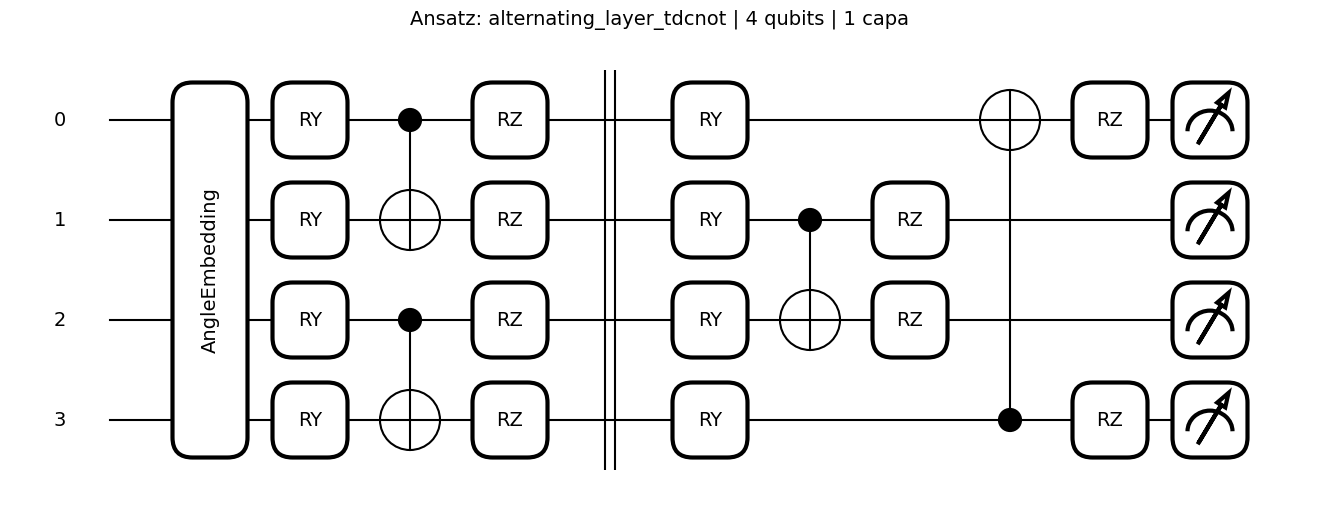

Figura guardada en: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\ansatz_figures\alternating_layer_tdcnot_4q_1layer.png
QNode encontrado en quantum_layer.circuit
Ansatz: farhi
num_qubits: 4 | num_quantum_layers: 1
0: ─╭AngleEmbedding(M0)─╭X────────────╭X───────────────────────────────────╭X────────────╭X─── ···
1: ─├AngleEmbedding(M0)─│─────────────│──╭X────────────╭X──────────────────│─────────────│──╭X ···
2: ─├AngleEmbedding(M0)─│─────────────│──│─────────────│──╭X────────────╭X─│─────────────│──│─ ···
3: ─╰AngleEmbedding(M0)─╰●──RX(-0.29)─╰●─╰●──RX(-0.25)─╰●─╰●──RX(-0.16)─╰●─╰●──RZ(-0.54)─╰●─╰● ···

0: ··· ───────────────────────────────┤  <Z>
1: ··· ────────────╭X─────────────────┤  <Z>
2: ··· ────────────│──╭X───────────╭X─┤  <Z>
3: ··· ──RZ(-0.01)─╰●─╰●──RZ(0.61)─╰●─┤  <Z>

M0 = 
tensor([0., 0., 0., 0.], dtype=torch.float64)


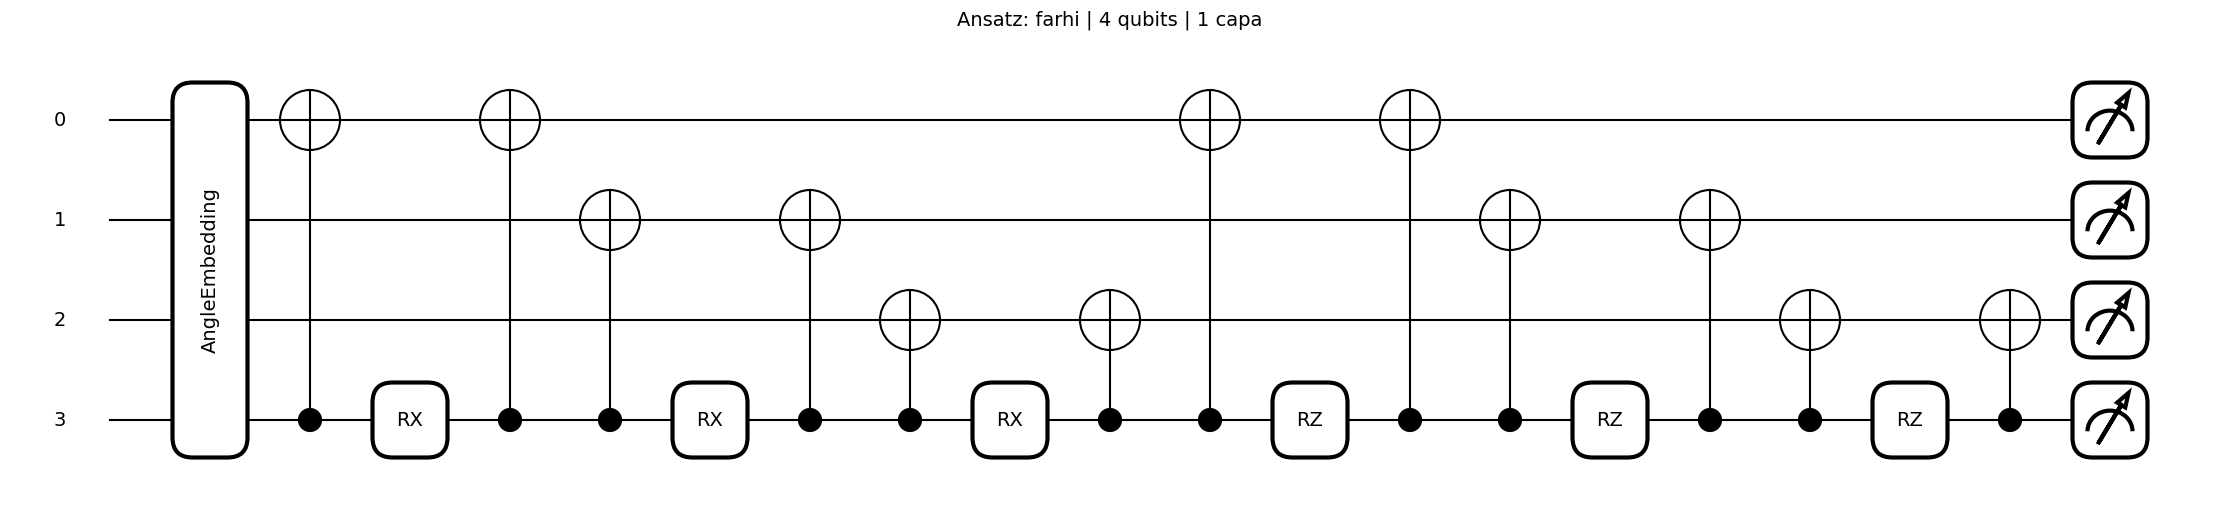

Figura guardada en: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\ansatz_figures\farhi_4q_1layer.png
QNode encontrado en quantum_layer.circuit
Ansatz: sim_circ_19
num_qubits: 4 | num_quantum_layers: 1
0: ─╭AngleEmbedding(M0)──RX(0.01)───RZ(-0.79)─╭||─╭X───────╭●─┤  <Z>
1: ─├AngleEmbedding(M0)──RX(0.25)───RZ(0.54)──├||─│─────╭●─╰X─┤  <Z>
2: ─├AngleEmbedding(M0)──RX(0.12)───RZ(0.38)──├||─│──╭●─╰X────┤  <Z>
3: ─╰AngleEmbedding(M0)──RX(-0.78)──RZ(-0.04)─╰||─╰●─╰X───────┤  <Z>

M0 = 
tensor([0., 0., 0., 0.], dtype=torch.float64)


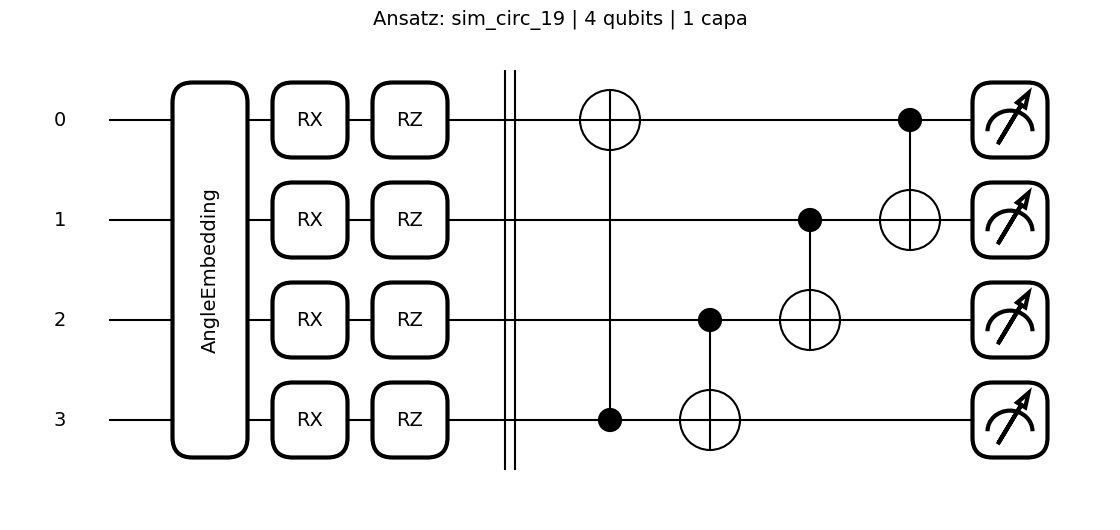

Figura guardada en: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\ansatz_figures\sim_circ_19_4q_1layer.png
QNode encontrado en quantum_layer.circuit
Ansatz: layered_circuit
num_qubits: 4 | num_quantum_layers: 1
0: ─╭AngleEmbedding(M0)──RZ(-0.44)──RX(0.19)──╭||─╭●───────╭X─╭||──RX(0.13)───RZ(-0.24)─┤  <Z>
1: ─├AngleEmbedding(M0)──RZ(-0.03)──RX(0.61)──├||─╰X─╭●────│──├||──RX(0.60)───RZ(0.23)──┤  <Z>
2: ─├AngleEmbedding(M0)──RZ(0.11)───RX(0.31)──├||────╰X─╭●─│──├||──RX(0.04)───RZ(-0.05)─┤  <Z>
3: ─╰AngleEmbedding(M0)──RZ(-0.15)──RX(-0.18)─╰||───────╰X─╰●─╰||──RX(-0.10)──RZ(0.20)──┤  <Z>

M0 = 
tensor([0., 0., 0., 0.], dtype=torch.float64)


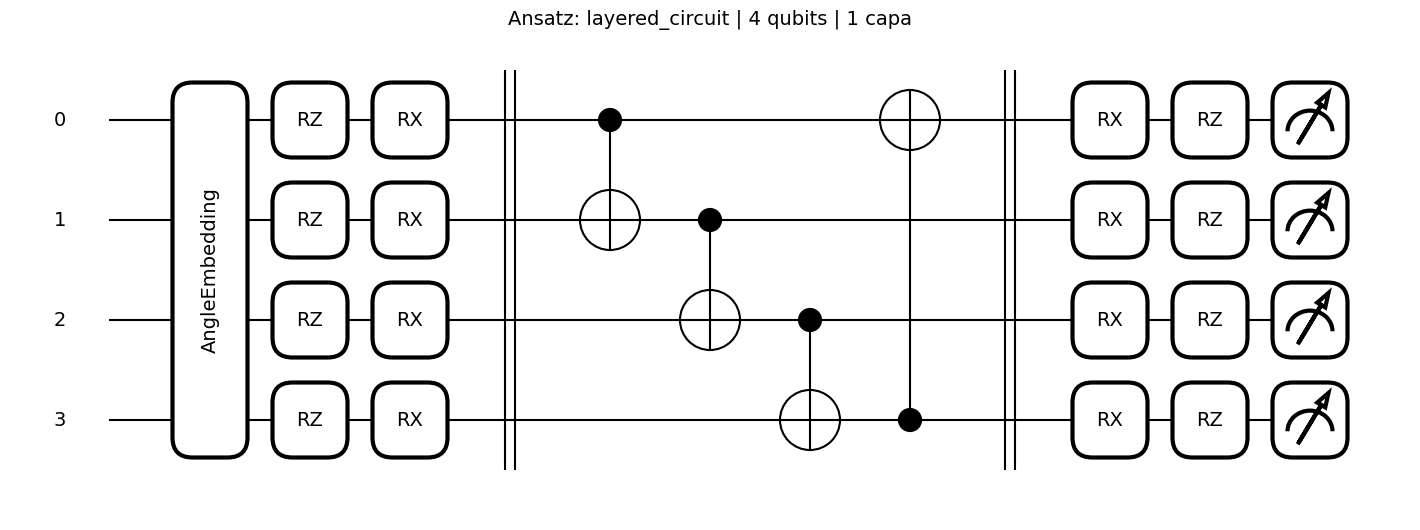

Figura guardada en: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\ansatz_figures\layered_circuit_4q_1layer.png


In [5]:
ansatz_list = [
    "alternating_layer_tdcnot",
    "farhi",
    "sim_circ_19",
    "layered_circuit",
]

for ans in ansatz_list:
    draw_ansatz(ans, show_ascii=True, save_png=True)

## Sugerencias para usar las figuras en la tesis

1. Ejecuta todo el notebook desde la raíz del repositorio.
2. Revisa las figuras guardadas en `results/ansatz_figures/`.
3. Si quieres un estilo homogéneo para metodología, puedes recortar o reescalar las imágenes exportadas manteniendo el mismo ancho.
4. Si alguna figura sale muy compacta, puedes repetir el dibujo con un tamaño mayor de figura después de `drawer_fig(x_draw)` usando `fig.set_size_inches(...)`.

QNode encontrado en quantum_layer.circuit


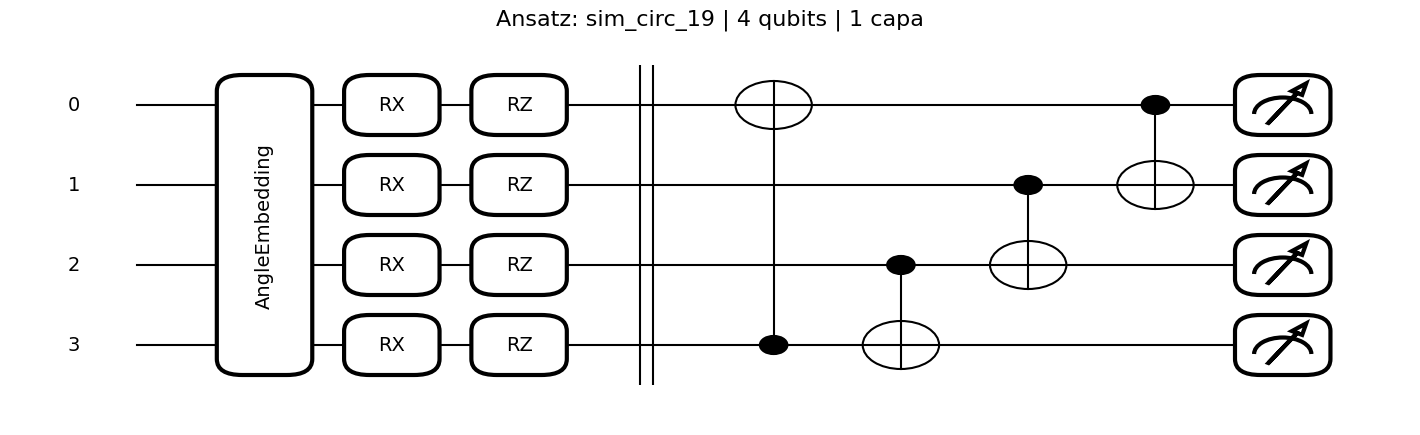

Versión ampliada guardada en: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\ansatz_figures\sim_circ_19_4q_1layer_large.png


In [6]:
# Opcional: volver a guardar una figura con un tamaño más grande
# Ejemplo con sim_circ_19

ans = "sim_circ_19"
model = build_model(ans)
qnode = get_qnode(model)
x_draw = make_dummy_features(model)

drawer_fig = qml.draw_mpl(qnode)
fig, ax = drawer_fig(x_draw)
fig.set_size_inches(14, 4)
fig.suptitle(f"Ansatz: {ans} | 4 qubits | 1 capa", y=1.04, fontsize=16)

big_path = OUT_DIR / f"{ans}_4q_1layer_large.png"
fig.savefig(big_path, dpi=400, bbox_inches="tight")
plt.show()

print("Versión ampliada guardada en:", big_path)